In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [2]:
# force 'normal' text style for math text
mpl.rcParams['mathtext.default'] = 'regular'

# set global seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [3]:
ts = pd.read_csv('/content/MOD-00685.csv')
COLS_TO_INCLUDE = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','pm25','co','o3','no','no2','rh','temp']
ts = ts[COLS_TO_INCLUDE]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31T18:59:17Z,8.543,0.676,0.158,0.029,0.024,0.003,14.082,704.365,22.673,2.293,31.660,51.2,-0.3
1,2025-12-31T18:58:17Z,9.063,0.708,0.125,0.023,0.030,0.006,11.505,711.399,21.543,2.083,32.586,51.7,-0.3
2,2025-12-31T18:57:17Z,8.758,0.714,0.158,0.022,0.024,0.006,13.275,711.470,21.912,2.083,32.354,51.6,-0.3
3,2025-12-31T18:56:17Z,9.603,0.839,0.190,0.033,0.023,0.006,9.174,709.702,22.318,2.293,32.133,51.2,-0.3
4,2025-12-31T18:55:17Z,8.368,0.627,0.147,0.044,0.015,0.012,13.823,721.159,22.325,2.228,32.130,51.1,-0.4


In [4]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local'],format="%Y-%m-%dT%H:%M:%SZ") #convert timestamp column to pandas timestamp format
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31 18:59:17,8.543,0.676,0.158,0.029,0.024,0.003,14.082,704.365,22.673,2.293,31.660,51.2,-0.3
1,2025-12-31 18:58:17,9.063,0.708,0.125,0.023,0.030,0.006,11.505,711.399,21.543,2.083,32.586,51.7,-0.3
2,2025-12-31 18:57:17,8.758,0.714,0.158,0.022,0.024,0.006,13.275,711.470,21.912,2.083,32.354,51.6,-0.3
3,2025-12-31 18:56:17,9.603,0.839,0.190,0.033,0.023,0.006,9.174,709.702,22.318,2.293,32.133,51.2,-0.3
4,2025-12-31 18:55:17,8.368,0.627,0.147,0.044,0.015,0.012,13.823,721.159,22.325,2.228,32.130,51.1,-0.4


## Full Timeseries Plot

In [5]:
#taking daily average of ts. round to floor of the day
ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-03-31,26.226533,4.094458,1.338863,0.414225,0.564025,0.447229,8.851858,890.080500,27.573250,2.304946,29.278171,85.990000,15.988333
2025-04-01,6.681117,0.878026,0.256594,0.058403,0.056508,0.032818,2.352943,681.025463,41.944498,2.113550,18.246839,47.092986,11.041111
2025-04-02,6.079411,0.672099,0.353091,0.136939,0.194472,0.160786,4.138132,710.805608,41.919482,1.962099,26.973906,44.383889,7.057847
2025-04-03,24.496704,3.763463,1.124998,0.370935,0.558131,0.494472,13.990290,793.886151,24.470972,2.212755,25.969107,79.522986,15.138819
2025-04-04,5.166757,0.451867,0.172857,0.054438,0.072224,0.052905,4.126440,712.707158,39.351213,2.038748,17.255623,45.271038,20.085344


In [6]:
ts_day['pm25_c'] = 3.491 + 0.576*ts_day['pm25'] - 0.047*ts_day['rh'] + 0.070*ts_day['temp']
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-03-31,26.226533,4.094458,1.338863,0.414225,0.564025,0.447229,8.851858,890.080500,27.573250,2.304946,29.278171,85.990000,15.988333,5.667324
2025-04-01,6.681117,0.878026,0.256594,0.058403,0.056508,0.032818,2.352943,681.025463,41.944498,2.113550,18.246839,47.092986,11.041111,3.405803
2025-04-02,6.079411,0.672099,0.353091,0.136939,0.194472,0.160786,4.138132,710.805608,41.919482,1.962099,26.973906,44.383889,7.057847,4.282571
2025-04-03,24.496704,3.763463,1.124998,0.370935,0.558131,0.494472,13.990290,793.886151,24.470972,2.212755,25.969107,79.522986,15.138819,8.871544
2025-04-04,5.166757,0.451867,0.172857,0.054438,0.072224,0.052905,4.126440,712.707158,39.351213,2.038748,17.255623,45.271038,20.085344,5.146065


<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-734212153.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)


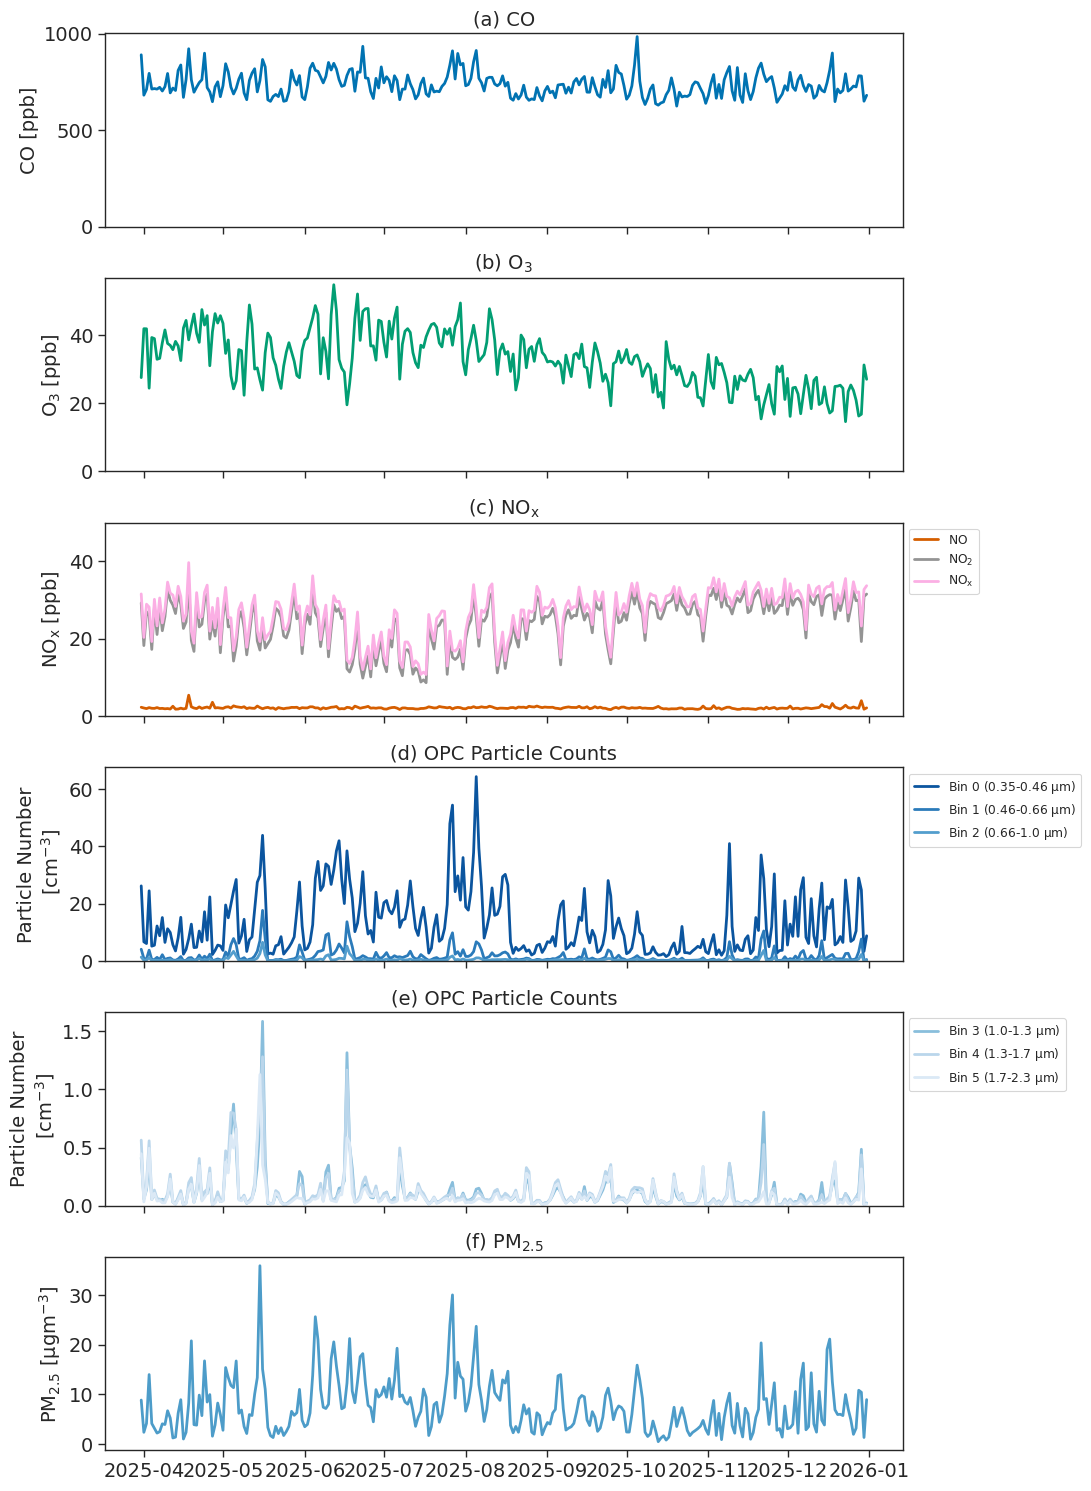

In [8]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(ts_day['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, None)

# plot the o3 on the second axis
ax[1].plot(ts_day['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, None)

#plot nox on the 2nd axis
ax[2].plot(ts_day['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(ts_day['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(ts_day['no2']+ts_day['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


# plot the OPC bins on the 5th and 6th rows
ax[3].plot(ts_day['bin0'], lw=2, label=r'Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(ts_day['bin1'], lw=2, label=r'Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(ts_day['bin2'], lw=2, label=r'Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(ts_day['bin3'], lw=2, label=r'Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(ts_day['bin4'], lw=2, label=r'Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(ts_day['bin5'], lw=2, label=r'Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(ts_day['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) OPC Particle Counts", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title("(f) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

# force a tight layout
plt.tight_layout()

fig.savefig('timeseries_MOD-00685.png')

## Dirunal Plots

In [9]:
#taking daily average of ts. round to floor of the day
ts_hour = ts.groupby(ts['timestamp_local'].dt.floor('h')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_hour = ts_hour.set_index('timestamp_local')
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-03-31 20:00:00,27.088833,2.756467,1.244433,0.493050,0.719067,0.567900,10.598833,892.475650,21.421050,1.915817,32.707800,80.868333,15.695000
2025-03-31 21:00:00,33.376733,4.492433,1.523833,0.489983,0.726600,0.629917,11.357133,909.377583,20.520050,2.373217,36.598883,87.250000,15.795000
2025-03-31 22:00:00,26.706517,5.287233,1.526450,0.420500,0.521900,0.408383,8.213233,908.361283,28.836500,2.450217,27.520233,88.866667,16.215000
2025-03-31 23:00:00,17.734050,3.841700,1.060733,0.253367,0.288533,0.182717,5.238233,850.107483,39.515400,2.480533,20.285767,86.975000,16.248333
2025-04-01 00:00:00,18.318567,3.750400,1.009083,0.235450,0.256600,0.169717,5.579017,760.029133,42.684067,2.339783,23.195200,85.893333,15.778333


In [10]:
ts_hour['pm25_c'] = 2.111 + 0.298*ts_hour['pm25'] + 0.024*ts_hour['rh'] + 0.050*ts_hour['temp']
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-03-31 20:00:00,27.088833,2.756467,1.244433,0.493050,0.719067,0.567900,10.598833,892.475650,21.421050,1.915817,32.707800,80.868333,15.695000,7.995042
2025-03-31 21:00:00,33.376733,4.492433,1.523833,0.489983,0.726600,0.629917,11.357133,909.377583,20.520050,2.373217,36.598883,87.250000,15.795000,8.379176
2025-03-31 22:00:00,26.706517,5.287233,1.526450,0.420500,0.521900,0.408383,8.213233,908.361283,28.836500,2.450217,27.520233,88.866667,16.215000,7.502094
2025-03-31 23:00:00,17.734050,3.841700,1.060733,0.253367,0.288533,0.182717,5.238233,850.107483,39.515400,2.480533,20.285767,86.975000,16.248333,6.571810
2025-04-01 00:00:00,18.318567,3.750400,1.009083,0.235450,0.256600,0.169717,5.579017,760.029133,42.684067,2.339783,23.195200,85.893333,15.778333,6.623904


In [11]:
#prepping data
ts_hour['Hour'] = ts_hour.index.hour
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-03-31 20:00:00,27.088833,2.756467,1.244433,0.493050,0.719067,0.567900,10.598833,892.475650,21.421050,1.915817,32.707800,80.868333,15.695000,7.995042,20
2025-03-31 21:00:00,33.376733,4.492433,1.523833,0.489983,0.726600,0.629917,11.357133,909.377583,20.520050,2.373217,36.598883,87.250000,15.795000,8.379176,21
2025-03-31 22:00:00,26.706517,5.287233,1.526450,0.420500,0.521900,0.408383,8.213233,908.361283,28.836500,2.450217,27.520233,88.866667,16.215000,7.502094,22
2025-03-31 23:00:00,17.734050,3.841700,1.060733,0.253367,0.288533,0.182717,5.238233,850.107483,39.515400,2.480533,20.285767,86.975000,16.248333,6.571810,23
2025-04-01 00:00:00,18.318567,3.750400,1.009083,0.235450,0.256600,0.169717,5.579017,760.029133,42.684067,2.339783,23.195200,85.893333,15.778333,6.623904,0


In [12]:
#groupping by hour and calculate the mean
diurnal_data = ts_hour.groupby('Hour').mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
Hour,,,,,,,,,,,,,,
00:00,13.414383,2.158825,0.648902,0.153075,0.158006,0.110351,7.996113,747.428045,29.786784,2.070806,26.820475,63.457595,16.309652,6.832306
01:00,13.637139,2.026200,0.567898,0.130212,0.140784,0.108203,7.851584,737.901936,28.993851,2.061471,26.435061,64.804679,15.951847,6.803677
02:00,13.947709,1.995888,0.539535,0.125203,0.139593,0.111464,7.668444,731.428168,28.018012,2.035794,26.418608,66.163053,15.597411,6.763980
03:00,14.112001,2.021328,0.544732,0.127774,0.143283,0.114479,7.533346,724.708113,27.222050,2.011458,25.911209,67.163137,15.269695,6.731337
04:00,14.395424,2.080004,0.571603,0.138294,0.155452,0.121646,7.476464,720.780633,26.400182,1.997189,25.752626,68.173342,14.984864,6.724390
05:00,14.867340,2.195057,0.606633,0.145733,0.160274,0.122138,7.425311,729.560246,25.225033,2.038495,26.066324,68.982786,14.786450,6.718652
06:00,15.030435,2.142457,0.589547,0.143009,0.157568,0.117844,7.333901,751.490083,24.191856,2.102959,26.006198,68.782193,14.814798,6.688015
07:00,14.844183,1.984957,0.525980,0.128346,0.147698,0.116862,7.587154,760.796244,24.831340,2.167879,24.167230,65.569566,15.703862,6.730835
08:00,14.497298,1.859926,0.493645,0.115998,0.128738,0.094441,7.547349,762.723944,26.791340,2.404442,21.709965,60.845342,17.140556,6.677426


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-1815338263.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipython-input-1815338263.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r

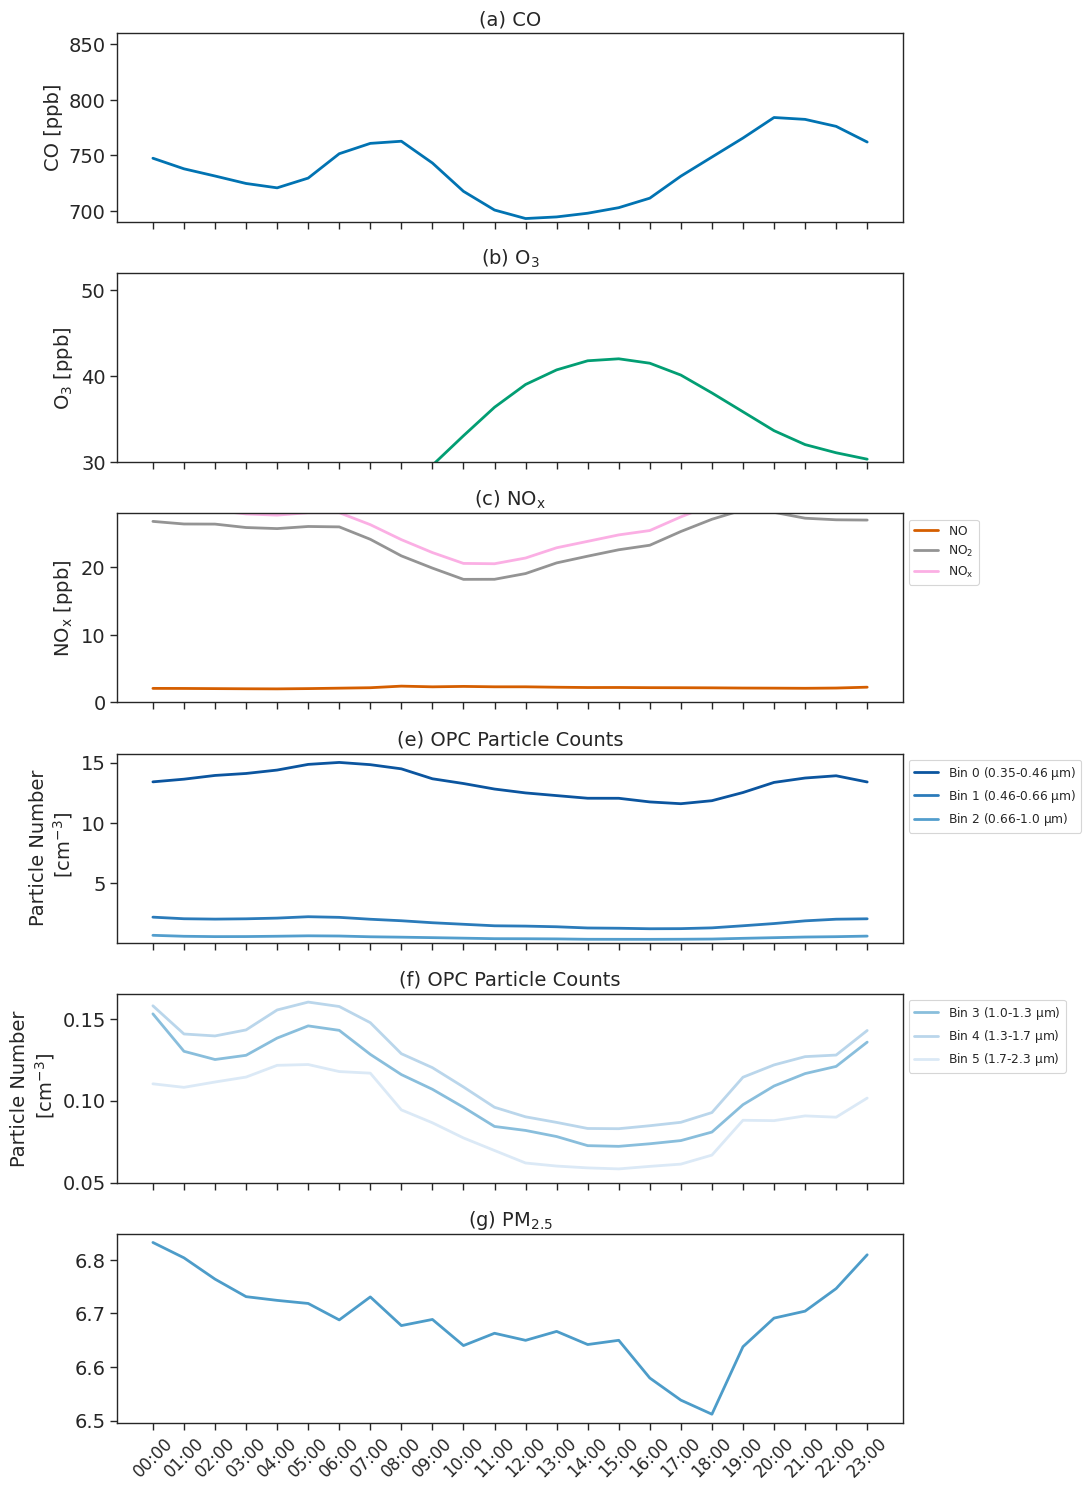

In [14]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(diurnal_data['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(690, 860)

# plot the o3 on the first axis
ax[1].plot(diurnal_data['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(30, 52)

#plot nox on the 2nd axis
ax[2].plot(diurnal_data['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(diurnal_data['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(diurnal_data['no2']+diurnal_data['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 28)

# plot the OPC bins on the 3rd and 4th rows
ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(diurnal_data['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0.05, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(diurnal_data['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(diurnal_data['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(diurnal_data['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0.05, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(diurnal_data['pm25_c'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(e) OPC Particle Counts", fontsize=14)
ax[4].set_title("(f) OPC Particle Counts", fontsize=14)
ax[5].set_title("(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# set x as hours
ax[5].set_xticks(range(24))
ax[5].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

plt.xticks(range(0, 24), size = 12)
plt.xticks(rotation=45)

# force a tight layout
plt.tight_layout()

fig.savefig('dirunal_MOD-00685_allfeatures.png')

## Diurnal by Season

In [15]:
def month_to_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [16]:
ts_hour = ts_hour.reset_index()

In [17]:
#prepping data
ts_hour['Season'] = ts_hour['timestamp_local'].dt.month.apply(month_to_season)
ts_hour.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour,Season
0,2025-03-31 20:00:00,27.088833,2.756467,1.244433,0.493050,0.719067,0.567900,10.598833,892.475650,21.421050,1.915817,32.707800,80.868333,15.695000,7.995042,20,Spring
1,2025-03-31 21:00:00,33.376733,4.492433,1.523833,0.489983,0.726600,0.629917,11.357133,909.377583,20.520050,2.373217,36.598883,87.250000,15.795000,8.379176,21,Spring
2,2025-03-31 22:00:00,26.706517,5.287233,1.526450,0.420500,0.521900,0.408383,8.213233,908.361283,28.836500,2.450217,27.520233,88.866667,16.215000,7.502094,22,Spring
3,2025-03-31 23:00:00,17.734050,3.841700,1.060733,0.253367,0.288533,0.182717,5.238233,850.107483,39.515400,2.480533,20.285767,86.975000,16.248333,6.571810,23,Spring
4,2025-04-01 00:00:00,18.318567,3.750400,1.009083,0.235450,0.256600,0.169717,5.579017,760.029133,42.684067,2.339783,23.195200,85.893333,15.778333,6.623904,0,Spring


In [18]:
grouped_by_season_hour = ts_hour.drop(columns='timestamp_local').groupby(['Season', 'Hour']).mean()
grouped_by_season_hour

bin0      bin1      bin2      bin3      bin4      bin5  \
Season Hour                                                                
Autumn 0      8.153876  1.313176  0.460634  0.117110  0.120708  0.078704   
       1      8.660946  1.082431  0.331804  0.082658  0.092984  0.071735   
       2      9.168314  1.092358  0.329176  0.083813  0.097396  0.076934   
       3      9.603955  1.166566  0.341385  0.085183  0.097609  0.077348   
       4     10.260525  1.180643  0.314079  0.076627  0.087972  0.070742   
...                ...       ...       ...       ...       ...       ...   
Winter 19    14.212588  1.400365  0.323723  0.062701  0.062412  0.041171   
       20    14.740883  1.472848  0.340348  0.065303  0.064804  0.043334   
       21    14.890554  1.627320  0.385869  0.076082  0.073522  0.049184   
       22    15.973220  2.108883  0.480616  0.093802  0.092924  0.059118   
       23    17.012097  2.451051  0.528669  0.095606  0.089560  0.056987   

                 pm25          co         o3        no        no2         rh  \
Season Hour                                                                    
Autumn 0     5.588837  733.879065  26.746966  2.003791  28.759372  62.244719   
       1     5.483048  731.740672  25.642597  1.994688  28.712660  64.090122   
       2     5.410966  726.771687  24.862688  1.938026  28.994905  65.727360   
       3     5.393929  720.094792  24.095073  1.930673  29.076887  66.962768   
       4     5.173478  712.889362  23.453077  1.925946  28.807029  67.999128   
...               ...         ...        ...       ...        ...        ...   
Winter 19    8.059385  742.814984  22.086425  2.123795  30.934317  56.818873   
       20    7.944626  747.072514  21.709697  2.165037  30.766817  57.305556   
       21    7.651016  741.665621  21.652001  2.174043  30.703989  58.092556   
       22    7.990961  732.592297  21.535191  2.181286  30.609159  59.600056   
       23    7.900712  730.635931  20.832528  2.326465  30.808609  61.311278   

                  temp    pm25_c  
Season Hour                       
Autumn 0     15.072491  6.023971  
       1     14.670047  6.016614  
       2     14.313801  6.016615  
       3     14.018071  6.026401  
       4     13.743687  5.971860  
...                ...       ...  
Winter 19     1.949824  5.973841  
       20     1.687667  5.938215  
       21     1.515833  5.861016  
       22     1.377944  5.991605  
       23     1.181500  5.995958  

[96 rows x 14 columns]

In [19]:
grouped_by_season_hour = grouped_by_season_hour.reset_index()
grouped_by_season_hour

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
0,Autumn,0,8.153876,1.313176,0.460634,0.117110,0.120708,0.078704,5.588837,733.879065,26.746966,2.003791,28.759372,62.244719,15.072491,6.023971
1,Autumn,1,8.660946,1.082431,0.331804,0.082658,0.092984,0.071735,5.483048,731.740672,25.642597,1.994688,28.712660,64.090122,14.670047,6.016614
2,Autumn,2,9.168314,1.092358,0.329176,0.083813,0.097396,0.076934,5.410966,726.771687,24.862688,1.938026,28.994905,65.727360,14.313801,6.016615
3,Autumn,3,9.603955,1.166566,0.341385,0.085183,0.097609,0.077348,5.393929,720.094792,24.095073,1.930673,29.076887,66.962768,14.018071,6.026401
4,Autumn,4,10.260525,1.180643,0.314079,0.076627,0.087972,0.070742,5.173478,712.889362,23.453077,1.925946,28.807029,67.999128,13.743687,5.971860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Winter,19,14.212588,1.400365,0.323723,0.062701,0.062412,0.041171,8.059385,742.814984,22.086425,2.123795,30.934317,56.818873,1.949824,5.973841
92,Winter,20,14.740883,1.472848,0.340348,0.065303,0.064804,0.043334,7.944626,747.072514,21.709697,2.165037,30.766817,57.305556,1.687667,5.938215
93,Winter,21,14.890554,1.627320,0.385869,0.076082,0.073522,0.049184,7.651016,741.665621,21.652001,2.174043,30.703989,58.092556,1.515833,5.861016
94,Winter,22,15.973220,2.108883,0.480616,0.093802,0.092924,0.059118,7.990961,732.592297,21.535191,2.181286,30.609159,59.600056,1.377944,5.991605


In [20]:
autumn_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Autumn']
winter_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Winter']
spring_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Spring']
summer_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Summer']

autumn_diurnal.index = autumn_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
winter_diurnal.index = winter_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
spring_diurnal.index = spring_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
summer_diurnal.index = summer_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))

In [21]:
autumn_diurnal

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
00:00,Autumn,0,8.153876,1.313176,0.460634,0.117110,0.120708,0.078704,5.588837,733.879065,26.746966,2.003791,28.759372,62.244719,15.072491,6.023971
01:00,Autumn,1,8.660946,1.082431,0.331804,0.082658,0.092984,0.071735,5.483048,731.740672,25.642597,1.994688,28.712660,64.090122,14.670047,6.016614
02:00,Autumn,2,9.168314,1.092358,0.329176,0.083813,0.097396,0.076934,5.410966,726.771687,24.862688,1.938026,28.994905,65.727360,14.313801,6.016615
03:00,Autumn,3,9.603955,1.166566,0.341385,0.085183,0.097609,0.077348,5.393929,720.094792,24.095073,1.930673,29.076887,66.962768,14.018071,6.026401
04:00,Autumn,4,10.260525,1.180643,0.314079,0.076627,0.087972,0.070742,5.173478,712.889362,23.453077,1.925946,28.807029,67.999128,13.743687,5.971860
05:00,Autumn,5,10.972536,1.441364,0.401707,0.094808,0.100118,0.072306,5.268484,718.522542,22.342056,1.941792,29.222639,69.091411,13.564803,6.017442
06:00,Autumn,6,11.371088,1.590418,0.457129,0.104959,0.105143,0.073401,5.383626,740.178588,21.011440,1.966519,29.493204,69.801084,13.362348,6.058664
07:00,Autumn,7,11.329589,1.404866,0.390087,0.093316,0.099621,0.073005,5.568175,750.269549,21.205506,1.982666,28.347895,67.667603,13.858745,6.087276
08:00,Autumn,8,10.464439,1.179760,0.335124,0.084306,0.097752,0.073727,6.027772,758.687928,23.200440,2.152875,24.628371,62.434213,15.364401,6.173917
09:00,Autumn,9,9.020845,1.024934,0.311251,0.080826,0.095898,0.071771,6.111190,736.364302,25.973883,2.187092,21.697632,56.656629,17.099944,6.146891


In [22]:
seasons_order = [winter_diurnal, spring_diurnal, summer_diurnal, autumn_diurnal]

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-118033659.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipython-input-118033659.py:41: SyntaxWarning: invalid escape sequence '\m'
  

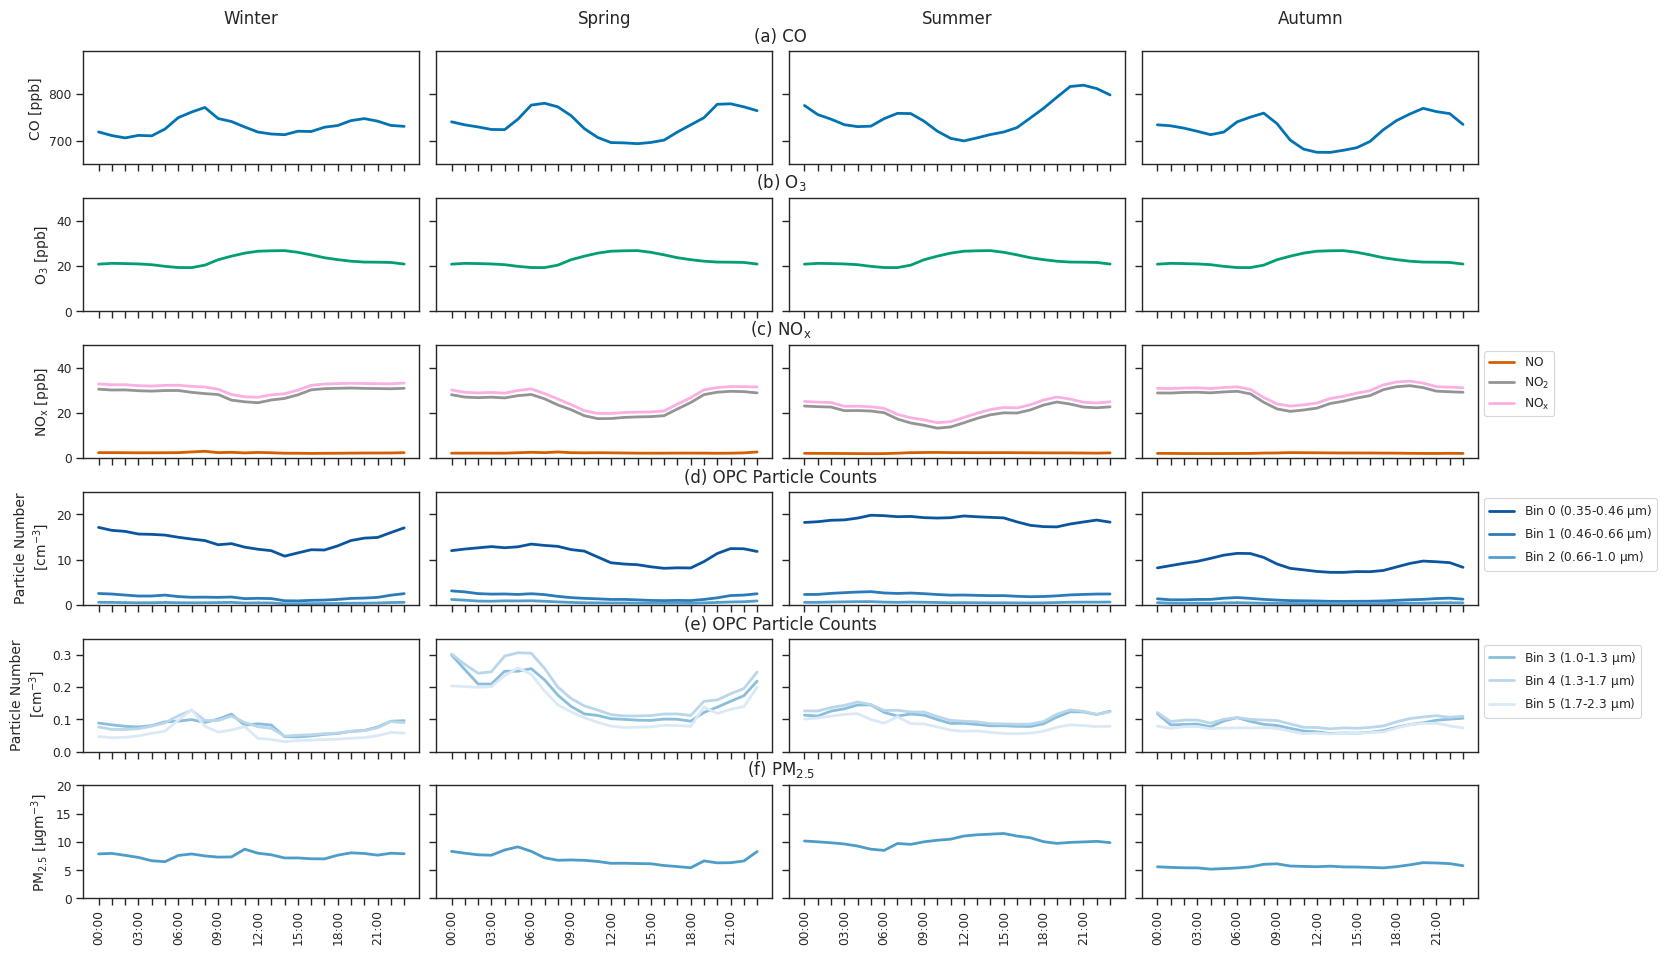

In [24]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(18,11), sharex=True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.05)

# grab the current color palette
cmap = sns.color_palette()

#iterate through seasons
for i in range(len(seasons_order)):

    #set ax column labels as season
    ax[0,0].set_title("Winter", fontsize=12, pad = 20)
    ax[0,1].set_title("Spring", fontsize=12, pad = 20)
    ax[0,2].set_title("Summer", fontsize=12, pad = 20)
    ax[0,3].set_title("Autumn", fontsize=12, pad = 20)

    # plot the CO data and label the axis
    ax[0,0].set_ylabel("CO [ppb]", fontsize=10)
    ax[0,i].plot(seasons_order[i]['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
    ax[0,i].set_ylim(650, 890)
    ax[0,i].set_xticks(range(0, 2))
    ax[0,i].set_xticks(seasons_order[i].index)

    # plot the o3 on the second axis
    ax[1,0].set_ylabel("$O_3$ [ppb]", fontsize=10)
    ax[1,i].plot(winter_diurnal['o3'], lw=2, label="$O_3$", color=cmap[2])
    ax[1,i].set_ylim(0, 50)

    #plot nox on the 3rd axis
    ax[2,0].set_ylabel("$NO_x$ [ppb]", fontsize=10)
    ax[2,i].plot(seasons_order[i]['no'], lw=2, label="$NO$", color=cmap[3])
    ax[2,i].plot(seasons_order[i]['no2'], lw=2, label="$NO_2$", color=cmap[7])
    ax[2,i].plot(seasons_order[i]['no2']+seasons_order[i]['no'], lw=2, label="$NO_x$", color=cmap[6])
    ax[2,i].set_ylim(0, 50)
    ax[2,3].legend(fontsize = 14)
    sns.move_legend(ax[2,3], "upper left", bbox_to_anchor=(1, 1))

    # plot the OPC bins on the 4th and 5th rows
    ax[3,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
    ax[3,i].plot(seasons_order[i]['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
    ax[3,i].plot(seasons_order[i]['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
    ax[3,i].set(ylim=(0, 25))
    ax[3,3].legend(fontsize = 14)
    sns.move_legend(ax[3,3], "upper left", bbox_to_anchor=(1, 1))

    ax[4,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[4,i].plot(seasons_order[i]['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
    ax[4,i].plot(seasons_order[i]['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
    ax[4,i].plot(seasons_order[i]['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
    ax[4,i].set(ylim=(0, 0.35))
    ax[4,3].legend(fontsize = 14)
    sns.move_legend(ax[4,3], "upper left", bbox_to_anchor=(1, 1))

    #plot pm25 on the 6th row
    ax[5,0].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=10)
    ax[5,i].plot(seasons_order[i]['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
    ax[5,i].set(ylim=(0, 20))
    ax[5,i].set_xticklabels(['00:00','','','03:00','','','06:00','','','09:00','','','12:00','','','15:00','','','18:00','','','21:00','',''], rotation=90)

    #remove subplot y ticks for subplots beyond winter
    if i>0:
        for j in range(6):
            ax[j,i].set_yticklabels([])

    # set titles for each panel
    row_titles = [
    "(a) CO",
    "(b) $O_3$",
    "(c) $NO_x$",
    "(d) OPC Particle Counts",
    "(e) OPC Particle Counts",
    "(f) $PM_{2.5}$"
]

for r, title in enumerate(row_titles):

    # left and right subplot positions
    left = ax[r,0].get_position()
    right = ax[r,-1].get_position()

    # horizontal center between first and last column
    x_center = (left.x0 + right.x1) / 2

    # slightly above the row
    y_top = left.y1 + 0.005

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=12
    )

fig.savefig('diurnal_by_season_MOD-00685.png')